# CIFAR-10 CNN Progression with Native PyTorch

This workflow preserves both archived stages: the simple model receives five
epochs and the advanced model receives its documented 25-epoch budget. Only
the model selected from validation accuracy is evaluated on the test set.

## Runtime dependency check

In [1]:
import importlib.util
import subprocess
import sys
from pathlib import Path

REQUIRED_RUNTIME = {'torch': 'torch'}
COLAB_EXTRAS = {}
missing_required = [
    package for module, package in REQUIRED_RUNTIME.items()
    if importlib.util.find_spec(module) is None
]
missing_extras = [
    package for module, package in COLAB_EXTRAS.items()
    if importlib.util.find_spec(module) is None
]
if missing_extras and "google.colab" in sys.modules:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", *missing_extras]
    )
    missing_extras = []
if missing_required or missing_extras:
    missing = ", ".join(missing_required + missing_extras)
    raise RuntimeError(
        f"Missing notebook dependencies: {missing}. Locally run "
        "`uv sync --group notebooks`; in Colab restart the runtime if an "
        "installation cell just changed the environment."
    )
print("runtime dependency check passed")

runtime dependency check passed


In [2]:
%matplotlib inline

## Imports and reproducibility

In [3]:
import hashlib
import json
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets

print(f"PyTorch {torch.__version__}")

PyTorch 2.13.0


## Load data and create the shared split

In [4]:
FAST_RUN = os.getenv("HELIO_FAST_RUN", "0") == "1"
SEED = 42
EPOCHS = 1 if FAST_RUN else 5
BATCH_SIZE = 64

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.use_deterministic_algorithms(True)
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)


data_root = Path(
    os.getenv("HELIO_DATA_DIR", Path.home() / ".cache" / "helio-data-methods")
)
development_dataset = datasets.CIFAR10(data_root, train=True, download=True)
test_dataset = datasets.CIFAR10(data_root, train=False, download=True)
x_development = development_dataset.data
y_development = np.asarray(development_dataset.targets)
x_test = test_dataset.data
y_test = np.asarray(test_dataset.targets)

all_indices = np.arange(len(y_development))
train_indices, validation_indices = train_test_split(
    all_indices,
    test_size=5000,
    random_state=SEED,
    stratify=y_development,
)
split_signature = hashlib.sha256(
    validation_indices.astype("<i8").tobytes()
).hexdigest()[:16]

if FAST_RUN:
    train_indices = train_indices[:2000]
    validation_indices = validation_indices[:500]
    x_test = x_test[:500]
    y_test = y_test[:500]

x_train = x_development[train_indices].astype("float32") / 255.0
y_train = y_development[train_indices].astype(np.int64)
x_validation = x_development[validation_indices].astype("float32") / 255.0
y_validation = y_development[validation_indices].astype(np.int64)
x_test = x_test.astype("float32") / 255.0
y_test = y_test.astype(np.int64)
x_train = np.transpose(x_train, (0, 3, 1, 2))
x_validation = np.transpose(x_validation, (0, 3, 1, 2))
x_test = np.transpose(x_test, (0, 3, 1, 2))

assert set(train_indices).isdisjoint(validation_indices)
print(f"split signature: {split_signature}")
print(
    f"train={len(y_train):,}, validation={len(y_validation):,}, "
    f"test={len(y_test):,}, epochs={EPOCHS}"
)

split signature: bfa7941b2b58be94
train=45,000, validation=5,000, test=10,000, epochs=5


## Inspect class coverage

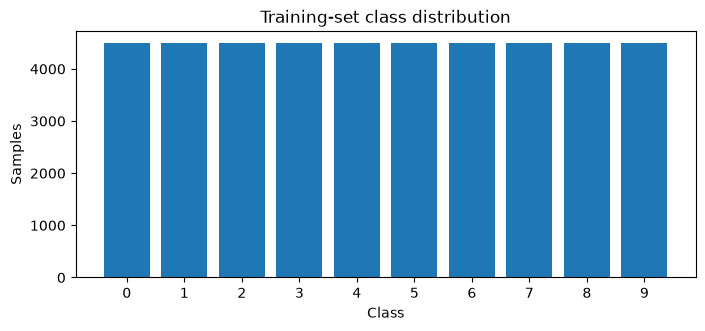

In [5]:
training_counts = np.bincount(y_train, minlength=10)
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.bar(np.arange(10), training_counts)
ax.set(
    title="Training-set class distribution",
    xlabel="Class",
    ylabel="Samples",
    xticks=np.arange(10),
)
plt.show()

## Simple source model — five epochs

In [6]:
EPOCHS = 1 if FAST_RUN else 5

In [7]:
class ImageClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3), nn.BatchNorm2d(16), nn.LeakyReLU(0.1),
            nn.Conv2d(16, 32, 3, stride=2), nn.BatchNorm2d(32), nn.LeakyReLU(0.1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(32 * 14 * 14, 100), nn.BatchNorm1d(100),
            nn.LeakyReLU(0.1), nn.Dropout(0.5), nn.Linear(100, 10),
        )

    def forward(self, values):
        return self.classifier(self.features(values))


model = ImageClassifier()
print(model)

ImageClassifier(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.1)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.1)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=6272, out_features=100, bias=True)
    (2): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): LeakyReLU(negative_slope=0.1)
    (4): Dropout(p=0.5, inplace=False)
    (5): Linear(in_features=100, out_features=10, bias=True)
  )
)


epoch 1: loss=1.4518, accuracy=0.4788, val_loss=1.4014, val_accuracy=0.5190


epoch 2: loss=1.1624, accuracy=0.5864, val_loss=1.1922, val_accuracy=0.5762


epoch 3: loss=1.0432, accuracy=0.6303, val_loss=1.0430, val_accuracy=0.6366


epoch 4: loss=0.9508, accuracy=0.6644, val_loss=1.1619, val_accuracy=0.6066


epoch 5: loss=0.8893, accuracy=0.6851, val_loss=0.9661, val_accuracy=0.6686


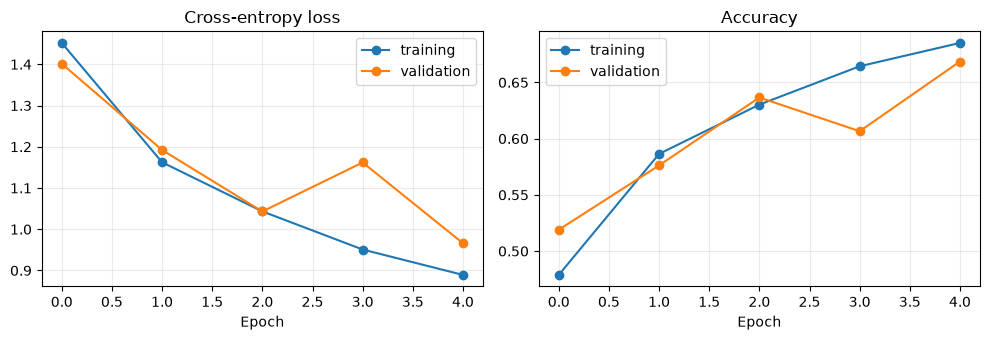

In [8]:
def tensor_dataset(images, labels):
    return TensorDataset(torch.from_numpy(images), torch.from_numpy(labels).long())


generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(
    tensor_dataset(x_train, y_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=generator,
)
validation_loader = DataLoader(
    tensor_dataset(x_validation, y_validation), batch_size=BATCH_SIZE
)
test_loader = DataLoader(tensor_dataset(x_test, y_test), batch_size=BATCH_SIZE)
model = model.to(DEVICE)
optimizer = torch.optim.Adam(model.parameters())
loss_function = nn.CrossEntropyLoss()
history = {"loss": [], "val_loss": [], "accuracy": [], "val_accuracy": []}


def epoch_pass(loader, training):
    model.train(training)
    total_loss = 0.0
    correct = 0
    for features, target in loader:
        features, target = features.to(DEVICE), target.to(DEVICE)
        if training:
            optimizer.zero_grad()
        logits = model(features)
        loss = loss_function(logits, target)
        if training:
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * len(target)
        correct += (logits.argmax(1) == target).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)


for epoch in range(EPOCHS):
    train_loss, train_accuracy = epoch_pass(train_loader, True)
    with torch.no_grad():
        validation_loss, validation_accuracy = epoch_pass(validation_loader, False)
    history["loss"].append(train_loss)
    history["accuracy"].append(train_accuracy)
    history["val_loss"].append(validation_loss)
    history["val_accuracy"].append(validation_accuracy)
    print(
        f"epoch {epoch + 1}: loss={train_loss:.4f}, accuracy={train_accuracy:.4f}, "
        f"val_loss={validation_loss:.4f}, val_accuracy={validation_accuracy:.4f}"
    )

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(history["loss"], marker="o", label="training")
axes[0].plot(history["val_loss"], marker="o", label="validation")
axes[0].set(title="Cross-entropy loss", xlabel="Epoch")
axes[1].plot(history["accuracy"], marker="o", label="training")
axes[1].plot(history["val_accuracy"], marker="o", label="validation")
axes[1].set(title="Accuracy", xlabel="Epoch")
for axis in axes:
    axis.legend()
    axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [9]:
simple_model = model
simple_history = {key: list(value) for key, value in history.items()}
simple_validation = float(max(history["val_accuracy"]))

## Advanced source model — 25 epochs

In [10]:
EPOCHS = 1 if FAST_RUN else 25

In [11]:
class ImageClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3), nn.BatchNorm2d(32), nn.LeakyReLU(0.1),
            nn.Conv2d(32, 64, 3, stride=2), nn.BatchNorm2d(64), nn.LeakyReLU(0.1),
            nn.Conv2d(64, 128, 3, stride=2), nn.BatchNorm2d(128),
            nn.LeakyReLU(0.1), nn.Dropout(0.2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(128 * 6 * 6, 600), nn.BatchNorm1d(600),
            nn.LeakyReLU(0.1), nn.Dropout(0.25), nn.Linear(600, 150),
            nn.BatchNorm1d(150), nn.LeakyReLU(0.1), nn.Dropout(0.5),
            nn.Linear(150, 10),
        )

    def forward(self, values):
        return self.classifier(self.features(values))


model = ImageClassifier()
print(model)

ImageClassifier(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.1)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.1)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.1)
    (9): Dropout(p=0.2, inplace=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4608, out_features=600, bias=True)
    (2): BatchNorm1d(600, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): LeakyReLU(negative_slope=0.1)
    (4): Dropout(p=0.25, inplace=False)
    (5

epoch 1: loss=1.3993, accuracy=0.4977, val_loss=1.1589, val_accuracy=0.5936


epoch 2: loss=1.0661, accuracy=0.6249, val_loss=1.0218, val_accuracy=0.6350


epoch 3: loss=0.9213, accuracy=0.6784, val_loss=0.8800, val_accuracy=0.6858


epoch 4: loss=0.8094, accuracy=0.7173, val_loss=0.8827, val_accuracy=0.6852


epoch 5: loss=0.7258, accuracy=0.7449, val_loss=0.7750, val_accuracy=0.7232


...

epoch 21: loss=0.1732, accuracy=0.9396, val_loss=1.0731, val_accuracy=0.7220


epoch 22: loss=0.1707, accuracy=0.9414, val_loss=0.9897, val_accuracy=0.7540


epoch 23: loss=0.1562, accuracy=0.9459, val_loss=0.9369, val_accuracy=0.7638


epoch 24: loss=0.1499, accuracy=0.9483, val_loss=1.0038, val_accuracy=0.7544


epoch 25: loss=0.1491, accuracy=0.9493, val_loss=1.0767, val_accuracy=0.7400


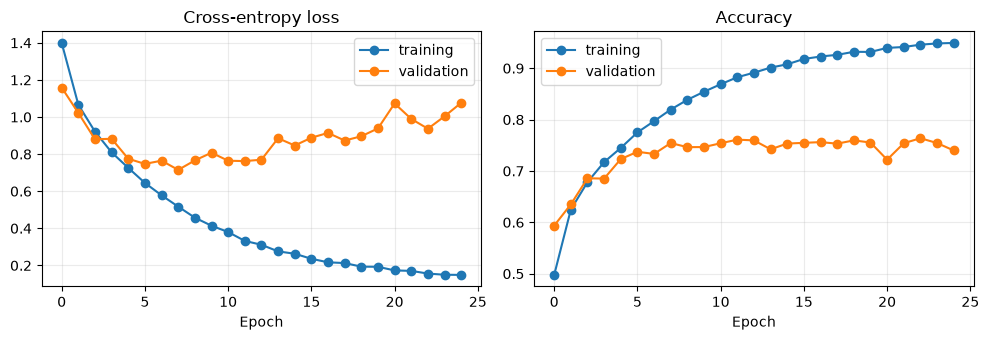

In [12]:
def tensor_dataset(images, labels):
    return TensorDataset(torch.from_numpy(images), torch.from_numpy(labels).long())


generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(
    tensor_dataset(x_train, y_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=generator,
)
validation_loader = DataLoader(
    tensor_dataset(x_validation, y_validation), batch_size=BATCH_SIZE
)
test_loader = DataLoader(tensor_dataset(x_test, y_test), batch_size=BATCH_SIZE)
model = model.to(DEVICE)
optimizer = torch.optim.Adam(model.parameters())
loss_function = nn.CrossEntropyLoss()
history = {"loss": [], "val_loss": [], "accuracy": [], "val_accuracy": []}


def epoch_pass(loader, training):
    model.train(training)
    total_loss = 0.0
    correct = 0
    for features, target in loader:
        features, target = features.to(DEVICE), target.to(DEVICE)
        if training:
            optimizer.zero_grad()
        logits = model(features)
        loss = loss_function(logits, target)
        if training:
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * len(target)
        correct += (logits.argmax(1) == target).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)


for epoch in range(EPOCHS):
    train_loss, train_accuracy = epoch_pass(train_loader, True)
    with torch.no_grad():
        validation_loss, validation_accuracy = epoch_pass(validation_loader, False)
    history["loss"].append(train_loss)
    history["accuracy"].append(train_accuracy)
    history["val_loss"].append(validation_loss)
    history["val_accuracy"].append(validation_accuracy)
    print(
        f"epoch {epoch + 1}: loss={train_loss:.4f}, accuracy={train_accuracy:.4f}, "
        f"val_loss={validation_loss:.4f}, val_accuracy={validation_accuracy:.4f}"
    )

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(history["loss"], marker="o", label="training")
axes[0].plot(history["val_loss"], marker="o", label="validation")
axes[0].set(title="Cross-entropy loss", xlabel="Epoch")
axes[1].plot(history["accuracy"], marker="o", label="training")
axes[1].plot(history["val_accuracy"], marker="o", label="validation")
axes[1].set(title="Accuracy", xlabel="Epoch")
for axis in axes:
    axis.legend()
    axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [13]:
advanced_model = model
advanced_history = {key: list(value) for key, value in history.items()}
advanced_validation = float(max(history["val_accuracy"]))

## Compare the source progression

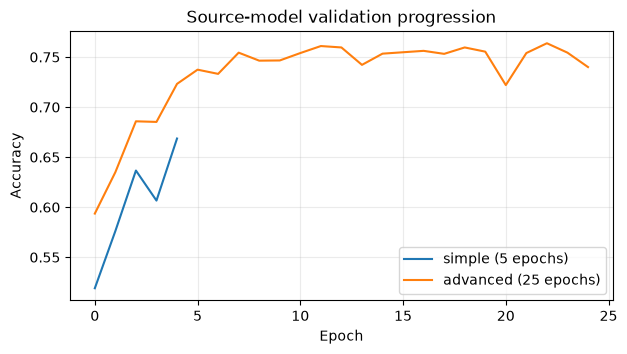

selected from validation evidence: advanced source model


In [14]:
if advanced_validation > simple_validation:
    selected_name, model = "advanced source model", advanced_model
else:
    selected_name, model = "simple source model", simple_model
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(simple_history["val_accuracy"], label="simple (5 epochs)")
ax.plot(advanced_history["val_accuracy"], label="advanced (25 epochs)")
ax.set(title="Source-model validation progression", xlabel="Epoch", ylabel="Accuracy")
ax.legend()
ax.grid(alpha=0.25)
plt.show()
print(f"selected from validation evidence: {selected_name}")

## Evaluate the selected source model once

test accuracy: 0.7380
              precision    recall  f1-score   support

           0      0.704     0.832     0.763      1000
           1      0.842     0.851     0.846      1000
           2      0.725     0.565     0.635      1000
           3      0.652     0.412     0.505      1000
           4      0.624     0.758     0.684      1000
           5      0.668     0.657     0.663      1000
           6      0.747     0.878     0.807      1000
           7      0.774     0.802     0.788      1000
           8      0.860     0.778     0.817      1000
           9      0.782     0.847     0.813      1000

    accuracy                          0.738     10000
   macro avg      0.738     0.738     0.732     10000
weighted avg      0.738     0.738     0.732     10000

HELIO_RESULT {"confusion_shape": [10, 10], "split_signature": "bfa7941b2b58be94", "test_accuracy": 0.738}


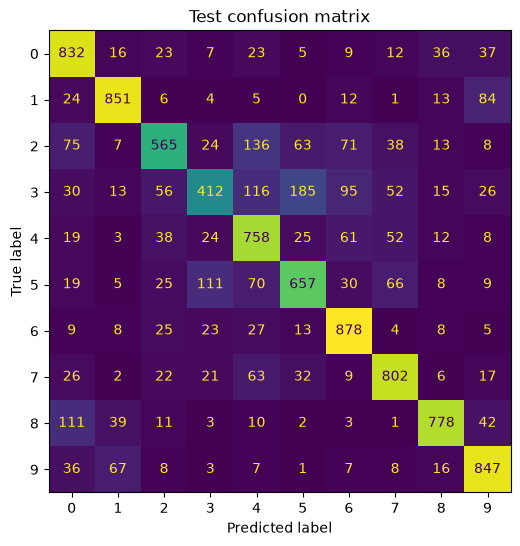

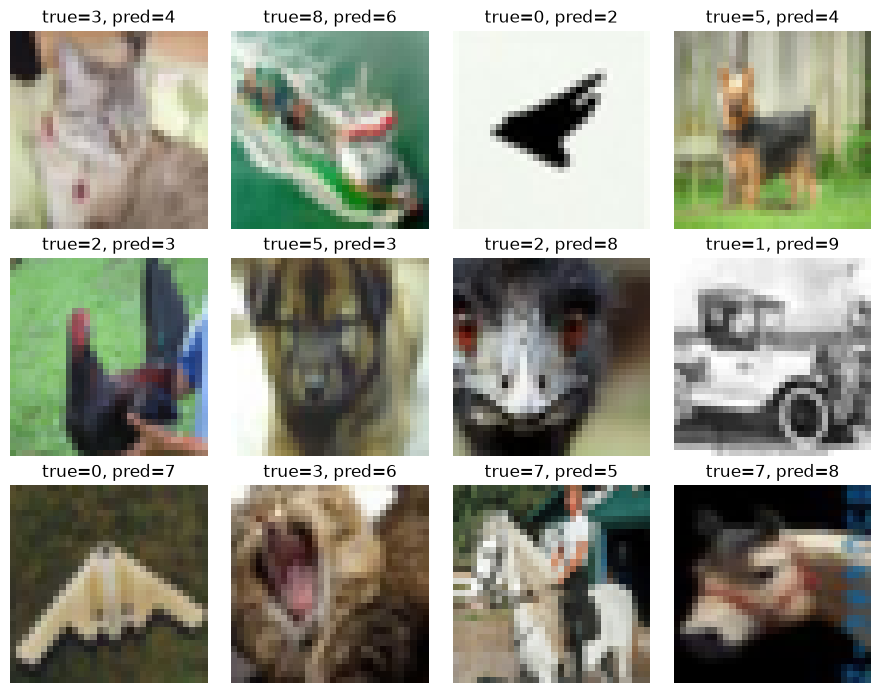

In [15]:
model.eval()
prediction_parts = []
with torch.no_grad():
    for features, _ in test_loader:
        prediction_parts.append(model(features.to(DEVICE)).argmax(1).cpu().numpy())
test_predictions = np.concatenate(prediction_parts)

test_accuracy = accuracy_score(y_test, test_predictions)
cm = confusion_matrix(y_test, test_predictions, labels=np.arange(10))
print(f"test accuracy: {test_accuracy:.4f}")
print(
    classification_report(
        y_test,
        test_predictions,
        labels=np.arange(10),
        digits=3,
        zero_division=0,
    )
)
print(
    "HELIO_RESULT "
    + json.dumps(
        {
            "split_signature": split_signature,
            "test_accuracy": float(test_accuracy),
            "confusion_shape": list(cm.shape),
        },
        sort_keys=True,
    )
)
assert cm.shape == (10, 10)

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=np.arange(10)).plot(
    ax=ax, colorbar=False, values_format="d"
)
ax.set_title("Test confusion matrix")
plt.show()

mistakes = np.flatnonzero(test_predictions != y_test)[:12]
if len(mistakes):
    fig, axes = plt.subplots(3, 4, figsize=(9, 7))
    for axis, index in zip(axes.flat, mistakes):
        image = x_test[index]
        if image.shape[0] in (1, 3):
            image = np.transpose(image, (1, 2, 0))
        axis.imshow(image.squeeze(), cmap="gray" if image.squeeze().ndim == 2 else None)
        axis.set_title(f"true={y_test[index]}, pred={test_predictions[index]}")
        axis.axis("off")
    plt.tight_layout()
    plt.show()

## Try it yourself

Change one choice at a time and keep the data split and evaluation unchanged:

- change the dropout in the advanced model.
- vary the third-stage filter count.
- compare how quickly the two models learn under a shorter budget.